In [1]:
from __future__ import print_function
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torchvision
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import torchvision.transforms as transforms

from torch.autograd import Variable
import pylab
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Standard MNIST preprocessing
transform = transforms.Compose([
    transforms.Resize(32), # Resizing to 32x32 often works better with DCGAN layers
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [2]:
num_gpu = 1 if torch.cuda.is_available() else 0
# load the models
from dcgan import Discriminator, Generator

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# 2. Load the weights using that device
D.load_state_dict(torch.load('weights/netD_epoch_99.pth', map_location=device))
G.load_state_dict(torch.load('weights/netG_epoch_99.pth', map_location=device))

# 3. Move the models to the device
D = D.to(device)
G = G.to(device)

Running on: cpu


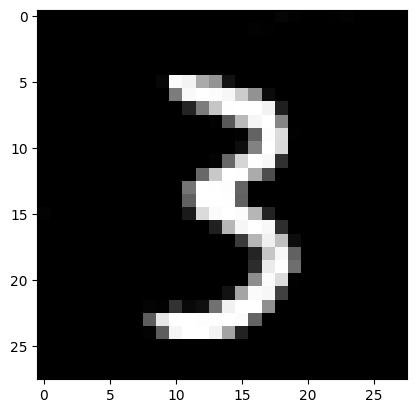

tensor([0.2045], grad_fn=<SqueezeBackward1>)  this shows that the image is mostly generator created (not a real dataset one)


In [4]:
vec = torch.randn(1,100, 1,1).to(device)
image_generated = G(vec)
shit = image_generated.cpu().detach().numpy().reshape(1,28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()
print(D(image_generated), " this shows that the image is mostly generator created (not a real dataset one)")

## training the inverese G+ 

z is the random data created in the latent space, G(z) + noise is the input to G*, whose output is z*, 

z* = G*(G(z) + noise)  

loss = ||z*  - z||^2

In [5]:
# defiing the G* architecture

class InverseGenerator(nn.Module):
    def __init__(self, ngpu, nc=1, nz=100, ndf=64):
        super(InverseGenerator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # Input is (nc) x 28 x 28
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf) x 14 x 14
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf*2) x 7 x 7
            # We use a kernel of 3 here to handle the odd 7x7 dimension transition
            nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False), 
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, nz, 4, 1, 0, bias=False),
            # Final output is (nz) x 1 x 1
        )

    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output

In [6]:
G_inv = InverseGenerator(ngpu=1).to(device)
G_inv.train()
optimizer = optim.Adam(G_inv.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.MSELoss()
epochs = 5000
batch_size = 512
latent_size = 100
noise_factor = 0.05

## training loop (ran on colab)

In [ ]:
print("Starting Training Loop...")

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 1. Generate a FRESH batch of random z for this epoch
    z_true = torch.randn(batch_size, latent_size, 1, 1).to(device)
        
    # 2. Generate perfect images from z (using no_grad to save memory!)
    with torch.no_grad():
        fake_images = G(z_true)
        
    # 3. Add synthetic corruption (noise)
    noise = torch.randn_like(fake_images) * noise_factor
    corrupted_images = fake_images + noise
    
    # 4. Pass the corrupted images through your Inverse Generator
    z_recovered = G_inv(corrupted_images)
    
    # 5. Calculate MSE Loss: |z* - z|^2
    loss = criterion(z_recovered, z_true)
    
    # 6. Backpropagation and optimization step
    loss.backward()
    optimizer.step()
    
    # 7. Print progress every 250 epochs
    if epoch % 250 == 0 or epoch == epochs - 1:
        print(f"Epoch [{epoch}/{epochs}] | MSE Loss: {loss.item():.6f}")
        
    # 8. Manually delete variables to free memory
    del z_true, fake_images, noise, corrupted_images, z_recovered, loss
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Training Complete!")

Starting Training Loop...
Epoch [0/5000] | MSE Loss: 1.172190
Epoch [250/5000] | MSE Loss: 0.930741
Epoch [500/5000] | MSE Loss: 0.922145


: 

## load the model and run it 

In [7]:
G_inv.eval()
G_inv.load_state_dict(torch.load('weights/G_inv_weights.pth', map_location=device))

<All keys matched successfully>

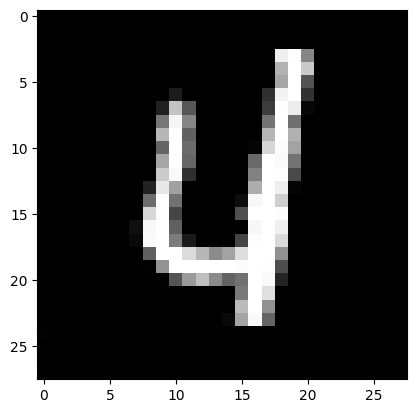

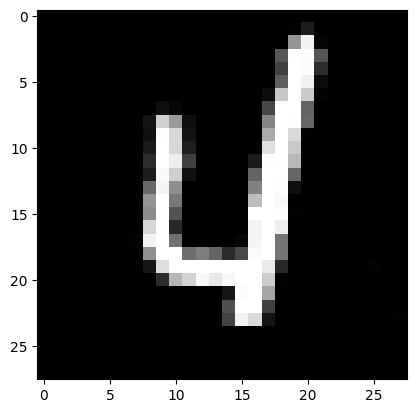

In [15]:
vec = torch.randn(1,100, 1,1).to(device)
image_generated = G(vec)
vec_generated = G_inv(image_generated)
shit = image_generated.cpu().detach().numpy().reshape(1,28,28)
inverse_image_generated = G(vec_generated).cpu().detach().numpy().reshape(28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()
plt.imshow(inverse_image_generated, cmap='gray')
plt.show()